## Cleaned URL dataset will be loading and preprocessing using NLP. The dataset will be trainning with 4 ML algorithms such as LG,NB,RF, and SVM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
url_data = pd.read_csv(r"C:\Users\vasil\OneDrive\ScamLens Dissertation\ScamLens Project\data\cleaned\url_cleaned.csv")

In [3]:
url_data.head(5)

,url,label
0,http://110.37.26.193:54956/bin.sh,1
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1
2,https://d6gu.ripple-cask.ru/jid43vpd,1
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1
4,https://bronze.systems,0


In [4]:
url_data.info

<bound method DataFrame.info of                                                      url  label
0                      http://110.37.26.193:54956/bin.sh      1
1               https://sentry5.obor1shwron8.ru/4ylkytvt      1
2                   https://d6gu.ripple-cask.ru/jid43vpd      1
3      http://130.12.180.34/596a96cc7bf9108cd896f33c4...      1
4                                 https://bronze.systems      0
...                                                  ...    ...
48807            https://zelnip.mo5hnap2sser.ru/b1a0bitj      1
48808                             https://ittefaq.com.bd      0
48809                                https://atidevs.com      0
48810         http://45.156.87.115/hiddenbin/boatnet.spc      1
48811                       http://175.30.47.193:50511/i      1

[48812 rows x 2 columns]>

In [5]:
url_data.columns

Index(['url', 'label'], dtype='object')

In [6]:
url_data['label'].value_counts()

label
1    24406
0    24406
Name: count, dtype: int64

In [7]:
url_data[url_data['label']==0].head()

,url,label
4,https://bronze.systems,0
5,https://ipwho.is,0
6,https://vbet.ua,0
7,https://ncplatform.net,0
14,https://colibriwp.com,0


In [8]:
url_data[url_data['label']==1].head()

,url,label
0,http://110.37.26.193:54956/bin.sh,1
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1
2,https://d6gu.ripple-cask.ru/jid43vpd,1
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1
8,http://222.137.23.188:37413/i,1


#### The cleaned URL dataset contains 48,812 rows and 2 columns. The label column represents 0 for legitimate URLs and 1 for phishing URLs. The URL column contains the website addresses used for classification.

#### A function was created to convert the [url] column into lowercase and remove the unusual spaces.

In [9]:
def clean_url(url):
    url = str(url).lower()
    url = url.strip()
    return url

#### A new column was created to after the function was applied on [url]column. This new column will be use for train and test dataset.

In [10]:
url_data['cleaned_url'] = url_data['url'].apply(clean_url)

In [11]:
url_data.head()

,url,label,cleaned_url
0,http://110.37.26.193:54956/bin.sh,1,http://110.37.26.193:54956/bin.sh
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,https://sentry5.obor1shwron8.ru/4ylkytvt
2,https://d6gu.ripple-cask.ru/jid43vpd,1,https://d6gu.ripple-cask.ru/jid43vpd
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,http://130.12.180.34/596a96cc7bf9108cd896f33c4...
4,https://bronze.systems,0,https://bronze.systems


#### The dataset was split into label and fueature, and sklearn model trtai_test_split was imported and applied.

In [12]:
X = url_data['cleaned_url']
y = url_data['label']

In [13]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size =0.2,
    random_state = 42,
    stratify = y
)

#### Character-level TF-IDF vectorization was applied using n-grams of length 3 to 5 because URLs do not follow natural language sentence structures. Analyser was used to catch the charachters from the url links, while the ngram_range to create groups from 3 to 5 to catch suspicious URL patterns commonly associated with phishing websites.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer = 'char',
    ngram_range = (3,5)
)

#### TF-IDF was used fit_transform only on X_train set, while on the X_test was used only the transform to prevemt from fiture leaking of data.

In [15]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

# Applying Naive Bayes Algorithm

In [16]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf,y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)


In [17]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test,y_pred_nb)

print('Naive Bayes Acuuracy:', nb_accuracy)

Naive Bayes Acuuracy: 0.976646522585271


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_nb))



              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4882
           1       1.00      0.96      0.98      4881

    accuracy                           0.98      9763
   macro avg       0.98      0.98      0.98      9763
weighted avg       0.98      0.98      0.98      9763



In [19]:
from sklearn.metrics import confusion_matrix

url = confusion_matrix(y_test,y_pred_nb)
print(url)

[[4872   10]
 [ 218 4663]]


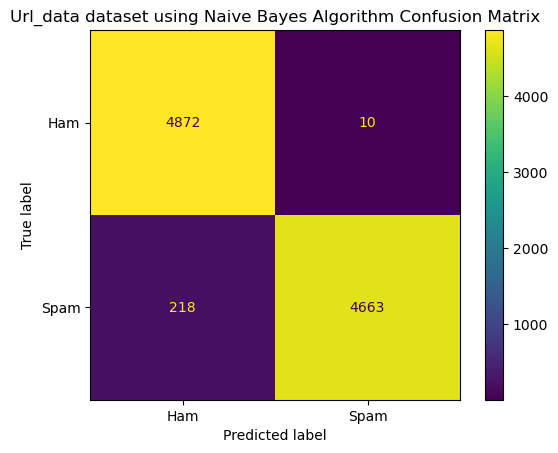

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels = ['Ham', 'Spam']
    
)
plt.title('Url_data dataset using Naive Bayes Algorithm Confusion Matrix')
plt.show()

# Analysis
#### The Naive Bayes algorithm achieved an accuracy score of 97.66% on the URL dataset. The model demonstrated strong classification performance for both legitimate and phishing URLs, with an F1-score of 0.98 for each class. The recall score of 1.00 for legitimate URLs indicates that almost all safe URLs were correctly identified. Furthermore, the model achieved a precision score of 1.00 for phishing URLs, meaning that URLs classified as phishing were almost always malicious. Overall, the results suggest that Naive Bayes is highly effective for URL classification when combined with character-level TF-IDF vectorisation.

# Applying Logistic Regression Algorithm

In [21]:
from sklearn.linear_model import LogisticRegression

lg_model = LogisticRegression()
lg_model.fit(X_train_tfidf,y_train)
y_pred_lg = lg_model.predict(X_test_tfidf)

In [22]:
from sklearn.metrics import accuracy_score

lg_accuracy = accuracy_score(y_test,y_pred_lg)
print('Logistic Regression Acuracy:',lg_accuracy)

Logistic Regression Acuracy: 0.9911912322032163


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_lg))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4882
           1       1.00      0.98      0.99      4881

    accuracy                           0.99      9763
   macro avg       0.99      0.99      0.99      9763
weighted avg       0.99      0.99      0.99      9763



In [24]:
from sklearn.metrics import confusion_matrix

url = confusion_matrix(y_test,y_pred_lg)
print(url)

[[4882    0]
 [  86 4795]]


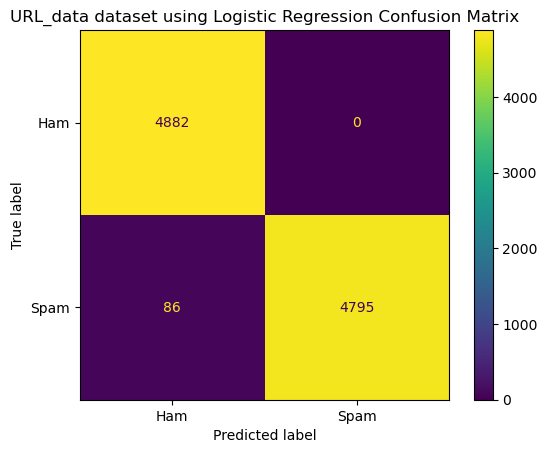

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lg,
    display_labels = ['Ham', 'Spam']
)
plt.title('URL_data dataset using Logistic Regression Confusion Matrix')
plt.show()

# Analysis
#### The Logistic Regression model achieved an accuracy score of 99.12% on the URL dataset, outperforming the Naive Bayes classifier. The model obtained an F1-score of 0.99 for both classes, demonstrating excellent classification capability. The confusion matrix revealed that all 4,882 legitimate URLs were correctly classified, resulting in zero false positives. Furthermore, 4,795 phishing URLs were successfully detected, with only 86 phishing URLs incorrectly classified as legitimate. These results indicate that Logistic Regression provides highly reliable performance for identifying malicious URLs while minimising incorrect classifications.

# Applying Support Vector Machine Algorithm

In [26]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
base_svm = LinearSVC()
svm_model = CalibratedClassifierCV(base_svm, cv =5)
svm_model.fit(X_train_tfidf,y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

In [27]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test,y_pred_svm)
print('Support Vector Machine Accuracy:', svm_accuracy)

Support Vector Machine Accuracy: 0.9979514493495851


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4882
           1       1.00      1.00      1.00      4881

    accuracy                           1.00      9763
   macro avg       1.00      1.00      1.00      9763
weighted avg       1.00      1.00      1.00      9763



In [29]:
from sklearn.metrics import confusion_matrix
url = confusion_matrix(y_test,y_pred_svm)
print(url)

[[4882    0]
 [  20 4861]]


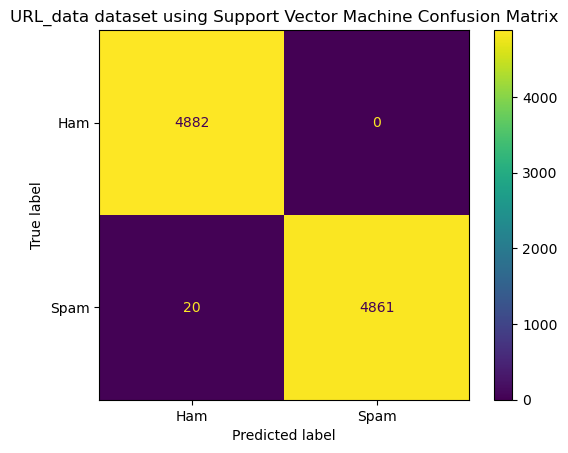

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels = ['Ham', 'Spam']
)
plt.title('URL_data dataset using Support Vector Machine Confusion Matrix')
plt.show()

# Analysis
#### The Support Vector Machine (SVM) classifier achieved the highest performance among all tested algorithms on the URL dataset, obtaining an accuracy score of 99.79%. The model produced F1-scores of 1.00 for both legitimate and phishing URL classes, demonstrating exceptional classification capability. The confusion matrix showed that all 4,882 legitimate URLs were correctly identified, resulting in zero false positives. Furthermore, 4,861 phishing URLs were correctly detected, while only 20 phishing URLs were misclassified as legitimate. These results indicate that SVM provides the most reliable and accurate solution for phishing URL detection and was therefore selected as the final model for integration into the ScamLens application.

# Applying Random Forest Algorithm

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf_model.fit(X_train_tfidf,y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

In [32]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test,y_pred_rf)
print('Random Forest Accuracy:',rf_accuracy)

Random Forest Accuracy: 0.9452012701014033


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      4882
           1       1.00      0.89      0.94      4881

    accuracy                           0.95      9763
   macro avg       0.95      0.95      0.95      9763
weighted avg       0.95      0.95      0.95      9763



In [34]:
from sklearn.metrics import confusion_matrix
url = confusion_matrix(y_test,y_pred_rf)
print(url)

[[4879    3]
 [ 532 4349]]


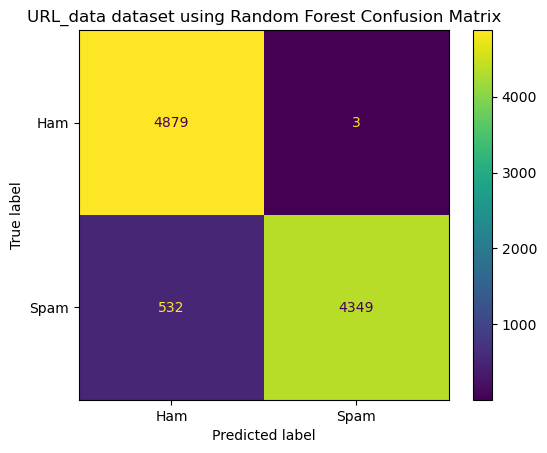

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels = ['Ham','Spam']
)
plt.title('URL_data dataset using Random Forest Confusion Matrix')
plt.show()

# Analysis
#### Although Random Forest achieved a satisfactory accuracy of 94.52%, its performance was significantly lower than the other evaluated models. The confusion matrix revealed that 532 phishing URLs were incorrectly classified as legitimate, resulting in a lower recall score of 0.89 for the phishing class. In contrast, the Support Vector Machine model misclassified only 29 phishing URLs and achieved an overall accuracy of 99.70%. Therefore, Random Forest was not selected for deployment within the ScamLens application.

#### Comparison Table of tested algorithms and achieved score

In [36]:
results = pd.DataFrame({
    'Model':['Naive Bayes','Logistic Regression','Support Vector Machine','Random Forest'],
    'Accuracy':[0.98,0.99,1.00,0.95],
    'Spam Recall':[1.00,1.00,1.00,1.00],
    'Spam F1':[0.98,0.99,1.00,0.95]
})

In [37]:
results

,Model,Accuracy,Spam Recall,Spam F1
0,Naive Bayes,0.98,1.0,0.98
1,Logistic Regression,0.99,1.0,0.99
2,Support Vector Machine,1.00,1.0,1.00
3,Random Forest,0.95,1.0,0.95


#### The SVM model was performed and achieved the best results among other algorithms, achieved accuracy, recall score, and F1 score 1.00. The model was saved in the models folder where the model will be used into ScamLens. Moreover, TF-IDF Vectorizer model was saved as well into models folder.

In [38]:
import joblib
joblib.dump(svm_model,'../models/url_svm_model.pkl')

['../models/url_svm_model.pkl']

In [39]:
joblib.dump(tfidf,'../models/url_tfidf.pkl')

['../models/url_tfidf.pkl']